In [3]:
# import numpy as np
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 22.0 MB/s  0:00:00m0:00:010:01

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 22.9 MB/s  0:00:00m0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Question 1

import numpy as np  
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])  
Perform the following without using explicit Python for loops: 
1. Calculate the mean of each row. 
2. Replace every element that is greater than its row mean by 1. 
3. Replace every other element by 0. 
4. Return the resulting binary matrix. 
5. Also determine which row contains the maximum number of elements 
above its row mean.

In [1]:
import numpy as np

A=np.array([[12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16]])
A

array([[12,  5,  8, 20],
       [ 7, 15,  3, 11],
       [25,  9, 18,  6],
       [10, 14,  2, 16]])

In [2]:
row_mean=np.mean(A,axis=1).reshape(-1,1)
row_mean

array([[11.25],
       [ 9.  ],
       [14.5 ],
       [10.5 ]])

In [3]:
bmat = np.where(A > row_mean,1,0)
bmat

array([[1, 0, 0, 1],
       [0, 1, 0, 1],
       [1, 0, 1, 0],
       [0, 1, 0, 1]])

In [4]:
count_above_mean = np.sum(bmat, axis=1)
count_above_mean

array([2, 2, 2, 2])

In [5]:
max_row = np.argmax(count_above_mean)
max_row

np.int64(0)

Question 2

X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15, 
115, 9] ]) 
For each column: 
1. Calculate the mean and standard deviation. 
2. Identify values satisfying: 
∣x−μ∣>2σ 
3. Replace such values with the corresponding column median. 
4. Do this without modifying non-outlier values. 

In [6]:
X=np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])
X

array([[ 10, 100,   5],
       [ 12, 110,   6],
       [ 11, 105,   7],
       [ 13, 500,   6],
       [ 14, 108,   8],
       [ 15, 115,   9]])

In [7]:
col_mean=np.mean(X,axis=0)
col_mean


array([ 12.5       , 173.        ,   6.83333333])

In [8]:
col_std=np.std(X,axis=0)
col_std

array([  1.70782513, 146.31017281,   1.34370962])

In [9]:
comparison_mat = np.abs(X - col_mean) > 2 * col_std
comparison_mat


array([[False, False, False],
       [False, False, False],
       [False, False, False],
       [False,  True, False],
       [False, False, False],
       [False, False, False]])

In [10]:
outlier=X[np.where(comparison_mat==True)]
outlier

array([500])

In [11]:
col_med=np.median(X,axis=0)
col_med

array([ 12.5, 109. ,   6.5])

In [12]:
# X_new=np.where(comparison_mat,col_med,X)
# X_new
X[comparison_mat==True]=np.median(X[:,1],axis=0)
X

array([[ 10, 100,   5],
       [ 12, 110,   6],
       [ 11, 105,   7],
       [ 13, 109,   6],
       [ 14, 108,   8],
       [ 15, 115,   9]])

Question 3

 
import pandas as pd  
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],  
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],  
'Gender': ['F','M','F','M','M','F','F','M'],  
'Marks': [85,72,91,65,78,88,95,70], 
'Attendance': [92,81,96,72,85,90,98,75] })  
Find: 
1. Average marks for each department. 
2. Average marks separately for each (Department, Gender) group. 
3. Student with the highest marks in each department. 
4. Students whose marks are above their department average. 
5. Department having the highest average attendance.

In [14]:
import pandas as pd

In [15]:
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],  
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],  
'Gender': ['F','M','F','M','M','F','F','M'],  
'Marks': [85,72,91,65,78,88,95,70], 
'Attendance': [92,81,96,72,85,90,98,75] }) 
df

,Student,Department,Gender,Marks,Attendance
0,A,CSE,F,85,92
1,B,CSE,M,72,81
2,C,ECE,F,91,96
3,D,ECE,M,65,72
4,E,CSE,M,78,85
5,F,ECE,F,88,90
6,G,CSE,F,95,98
7,H,ECE,M,70,75


In [16]:
avg_marks = df.groupby('Department')['Marks'].mean()
print(avg_marks)

Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64


In [17]:
avg_group = df.groupby(['Department', 'Gender'])['Marks'].mean()
print(avg_group)

Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64


In [18]:
highest = df.loc[df.groupby('Department')['Marks'].idxmax()]
print(highest)

  Student Department Gender  Marks  Attendance
6       G        CSE      F     95          98
2       C        ECE      F     91          96


In [19]:
dept_avg = df.groupby('Department')['Marks'].transform('mean')
above_avg = df[df['Marks'] > dept_avg]
print("\n4. Students Above Department Average:")
print(above_avg)


4. Students Above Department Average:
  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98


In [20]:
attendance_by_dept_avg=df.groupby('Department')['Attendance'].mean()
attendance_by_dept_avg.idxmax()
# attendance_by_dept_avg


'CSE'

Question 4

df = pd.DataFrame({ 'ID': [101,102,103,101,104,102,105],  
'Name': ['A','B','C','A','D','B','E'], 
'Age': [20,21,22,20,23,21,24],  
'Score': [80,75,90,85,88,75,92] })  
Perform: 
1. Identify duplicated IDs. 
2. For each ID, determine whether its records are identical. 
3. If multiple records exist for an ID, retain the record having the highest 
Score. 
4. Produce a clean DataFrame containing exactly one record per ID. 
5. Report how many records were removed.

In [21]:
df = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})
df

,ID,Name,Age,Score
0,101,A,20,80
1,102,B,21,75
2,103,C,22,90
3,101,A,20,85
4,104,D,23,88
5,102,B,21,75
6,105,E,24,92


In [22]:
dup_id=df.loc[df['ID'].duplicated(keep=False)]
# dup_id=df.loc[df['ID'].duplicated()]
dup_id

,ID,Name,Age,Score
0,101,A,20,80
1,102,B,21,75
3,101,A,20,85
5,102,B,21,75


In [23]:
df_identical = dup_id.duplicated(keep=False)

print(df_identical)

0    False
1     True
3    False
5     True
dtype: bool


row 0 and 3 are duplicate ids but not identical records , but row 1 and 5 are

In [24]:
df2 = df.sort_values('Score', ascending=False)
df2 = df.drop_duplicates('ID')
df2

,ID,Name,Age,Score
0,101,A,20,80
1,102,B,21,75
2,103,C,22,90
4,104,D,23,88
6,105,E,24,92


In [25]:
print(df2.sort_index())

    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
2  103    C   22     90
4  104    D   23     88
6  105    E   24     92


In [26]:
print("Records Removed : ", len(df)-len(df2))

Records Removed :  2


Question 5

df = pd.DataFrame({ 'Date': [ '2026-01-01', 
'2026-01-02', 
'2026-01-04', 
'2026-01-05', 
'2026-01-08', 
'2026-01-09' ],  
'Sales': [100,120,150,130,180,200] })  
Perform: 
1. Convert Date into a proper datetime column. 
2. Detect the missing dates. 
3. Reindex the DataFrame to contain every date between the minimum and 
maximum date. 
4. Keep missing sales as NaN. 
5. Calculate a 3-day rolling average of sales. 
6. Identify the date on which the rolling average is maximum.

In [27]:
df = pd.DataFrame({ 'Date': [ '2026-01-01', 
'2026-01-02', 
'2026-01-04', 
'2026-01-05', 
'2026-01-08', 
'2026-01-09' ],  
'Sales': [100,120,150,130,180,200] })  
df

,Date,Sales
0,2026-01-01,100
1,2026-01-02,120
2,2026-01-04,150
3,2026-01-05,130
4,2026-01-08,180
5,2026-01-09,200


In [28]:
df['Date']=pd.to_datetime(df['Date'])
df.dtypes

Date     datetime64[us]
Sales             int64
dtype: object

In [29]:
all_dates = pd.date_range(df['Date'].min(), df['Date'].max())

print(all_dates)

missing = all_dates.difference(df['Date'])


DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09'],
              dtype='datetime64[us]', freq='D')


In [30]:
print(missing)

DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[us]', freq=None)


In [31]:
all_dates = pd.date_range(df['Date'].min(), df['Date'].max())

df = df.set_index('Date')
df = df.reindex(all_dates)

print(df)

            Sales
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0


In [32]:
df['Rolling_Avg'] = df['Sales'].rolling(3, min_periods=1).mean()
print(df)

            Sales  Rolling_Avg
2026-01-01  100.0        100.0
2026-01-02  120.0        110.0
2026-01-03    NaN        110.0
2026-01-04  150.0        135.0
2026-01-05  130.0        140.0
2026-01-06    NaN        140.0
2026-01-07    NaN        130.0
2026-01-08  180.0        180.0
2026-01-09  200.0        190.0


In [33]:
df['Rolling_Avg'].idxmax()

Timestamp('2026-01-09 00:00:00')

Question 6

P = np.array([ [1, 2], [4, 6], [7, 3], [2, 8], [9, 5] ])  
Construct a 5×5 matrix where element (i,j) contains the Euclidean distance 
between points i and j. 
The solution must: 
● use NumPy broadcasting; 
● contain no for or while loop; 
● have zeros on the diagonal; 
● produce a symmetric matrix. 
Then identify the pair of points having the maximum distance. 

In [34]:
P = np.array([ [1, 2], [4, 6], [7, 3], [2, 8], [9, 5] ])  
P

array([[1, 2],
       [4, 6],
       [7, 3],
       [2, 8],
       [9, 5]])

In [35]:
diff = P[:, np.newaxis, :] - P[np.newaxis, :, :]


In [36]:
D = np.sqrt(np.sum(diff**2, axis=2))
print(D)

[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]


In [37]:
i, j = np.unravel_index(np.argmax(D), D.shape)

print("Maximum distance:", D[i, j])
print("Points:", P[i], "and", P[j])

Maximum distance: 8.54400374531753
Points: [1 2] and [9 5]


Question 7

Take 10 datasets from kaggle (Tabular datasets e.g. weather dataset, housing 
dataset, titanic dataset, etc.) Perform exploratory data analysis on the dataset using 
seaborn , matplotlib. (Draw graphs like bar chart, line chart, scatter plots, etc. and 
explain the insights). Also clean the dataset accordingly.

In [38]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 28.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 30.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [39]:
!python -c "import matplotlib; print(matplotlib.__version__)"

3.11.1


In [72]:
%pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


Dataset 1 titanic passenger survival

In [41]:
df = sns.load_dataset("titanic")
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [42]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Cleaning on dataset 1

In [43]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df = df.drop(columns=["deck"])
print("Shape after cleaning:", df.shape)
df.isna().sum()

Shape after cleaning: (891, 14)


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

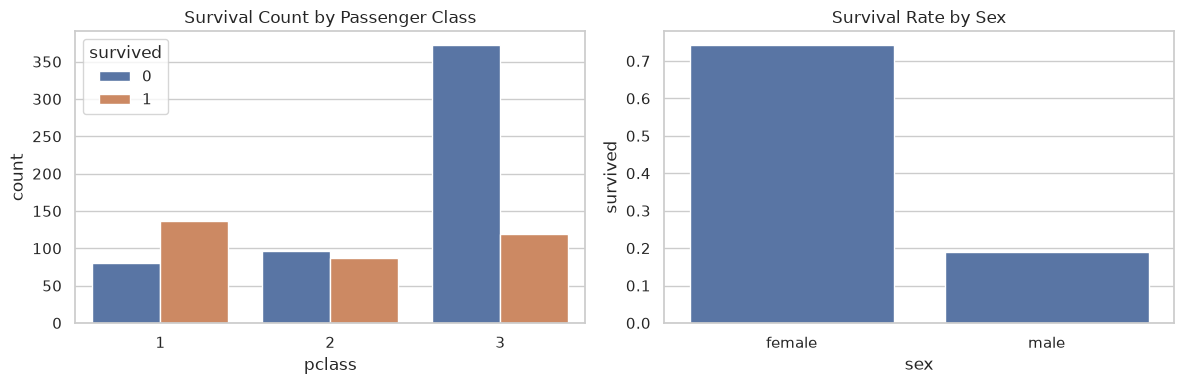

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df, x="pclass", hue="survived", ax=axes[0])
axes[0].set_title("Survival Count by Passenger Class")

rate = df.groupby("sex")["survived"].mean().reset_index()
sns.barplot(data=rate, x="sex", y="survived", ax=axes[1])
axes[1].set_title("Survival Rate by Sex")
plt.tight_layout(); plt.show()

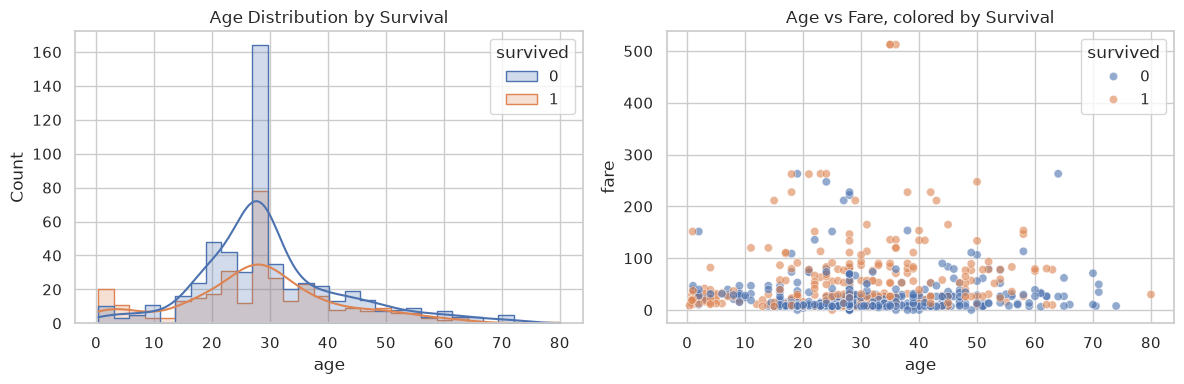

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True, ax=axes[0], element="step")
axes[0].set_title("Age Distribution by Survival")

sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=0.6, ax=axes[1])
axes[1].set_title("Age vs Fare, colored by Survival")
plt.tight_layout(); plt.show()

Dataset 2 restaurant tipping behaviour

In [46]:
df = sns.load_dataset("tips")
print("Shape:", df.shape, "| duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
df["tip_pct"] = df["tip"] / df["total_bill"] * 100
df.head()

Shape: (244, 7) | duplicates: 1


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


cleaning on dataset 2

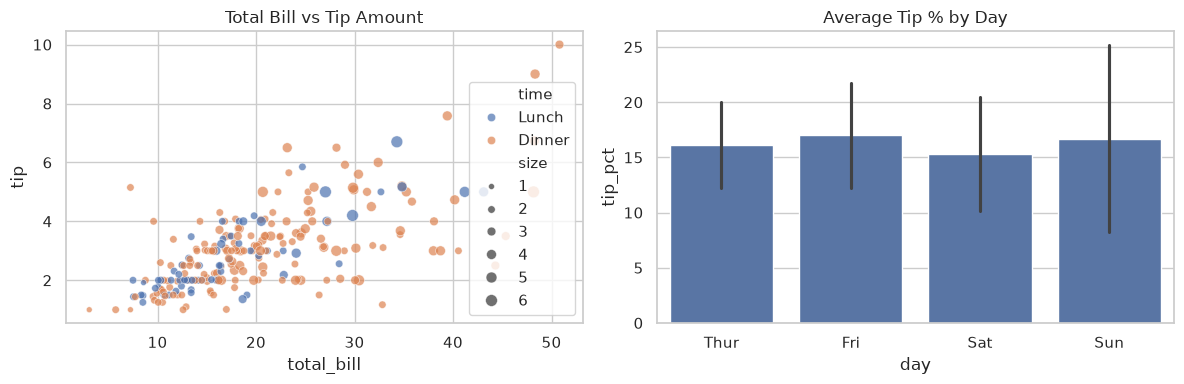

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", size="size", ax=axes[0], alpha=0.7)
axes[0].set_title("Total Bill vs Tip Amount")

order = ["Thur","Fri","Sat","Sun"]
sns.barplot(data=df, x="day", y="tip_pct", order=order, ax=axes[1], errorbar="sd")
axes[1].set_title("Average Tip % by Day")
plt.tight_layout(); plt.show()

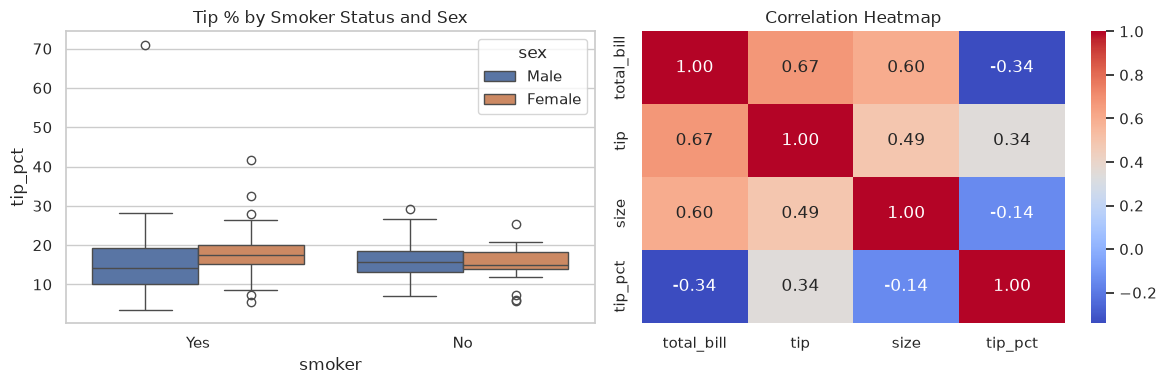

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x="smoker", y="tip_pct", hue="sex", ax=axes[0])
axes[0].set_title("Tip % by Smoker Status and Sex")

corr = df[["total_bill","tip","size","tip_pct"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1], fmt=".2f")
axes[1].set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

Dataset 3 pricing dataset

In [49]:
df = sns.load_dataset("diamonds")
print("Shape:", df.shape)
df = df.drop_duplicates()
bad_dim = ((df["x"]==0)|(df["y"]==0)|(df["z"]==0)).sum()
df = df[(df["x"]>0)&(df["y"]>0)&(df["z"]>0)]
q_hi = df["price"].quantile(0.999)
df = df[df["price"]<=q_hi]
print(f"Removed {bad_dim} rows with impossible 0mm dimensions, trimmed top 0.1% price outliers.")
print("Shape after cleaning:", df.shape)
df.head()

Shape: (53940, 10)
Removed 19 rows with impossible 0mm dimensions, trimmed top 0.1% price outliers.
Shape after cleaning: (53721, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


cleaning on dataset 3

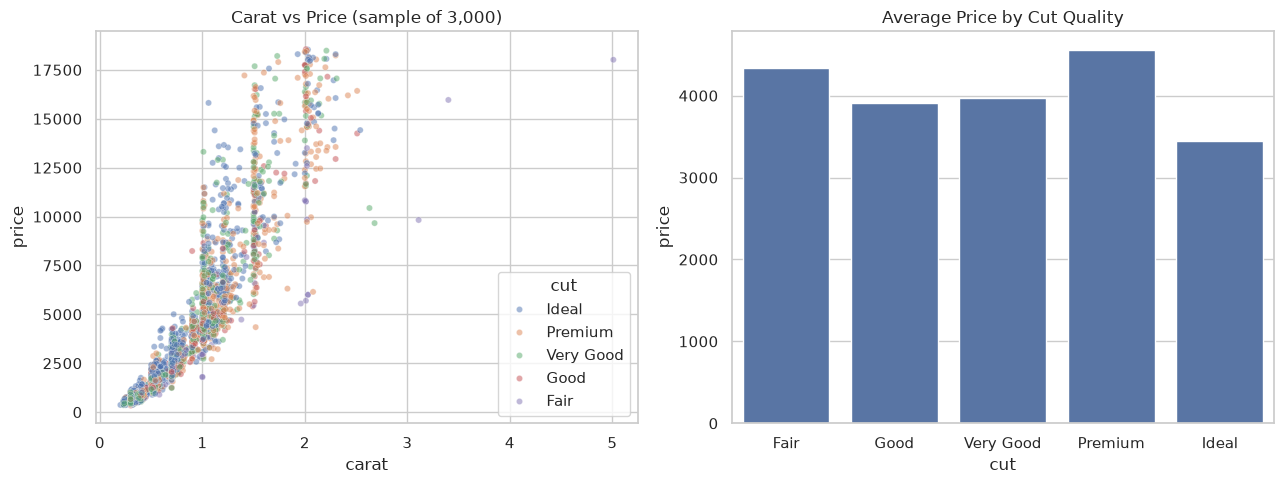

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sample = df.sample(3000, random_state=1)
sns.scatterplot(data=sample, x="carat", y="price", hue="cut", alpha=0.5, ax=axes[0], s=20)
axes[0].set_title("Carat vs Price (sample of 3,000)")

order = ["Fair","Good","Very Good","Premium","Ideal"]
sns.barplot(data=df, x="cut", y="price", order=order, ax=axes[1], errorbar=None)
axes[1].set_title("Average Price by Cut Quality")
plt.tight_layout(); plt.show()

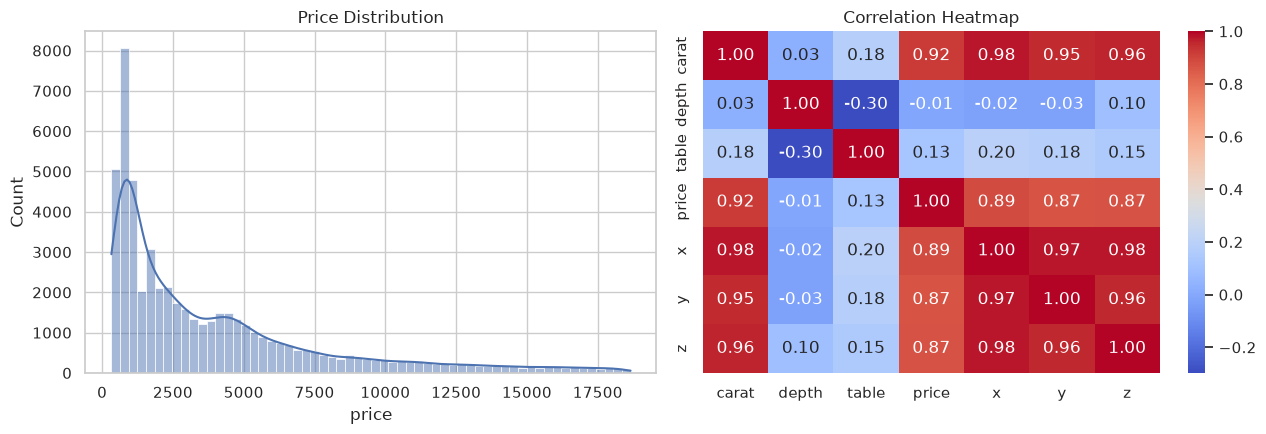

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(df["price"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")

corr = df[["carat","depth","table","price","x","y","z"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1], fmt=".2f")
axes[1].set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

dataset 4 : iris | classic species classification 

In [52]:
df = sns.load_dataset("iris")
print("Shape:", df.shape, "| duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)
df.head()

Shape: (150, 5) | duplicates: 1
Shape after cleaning: (149, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


cleaning on dataset 4

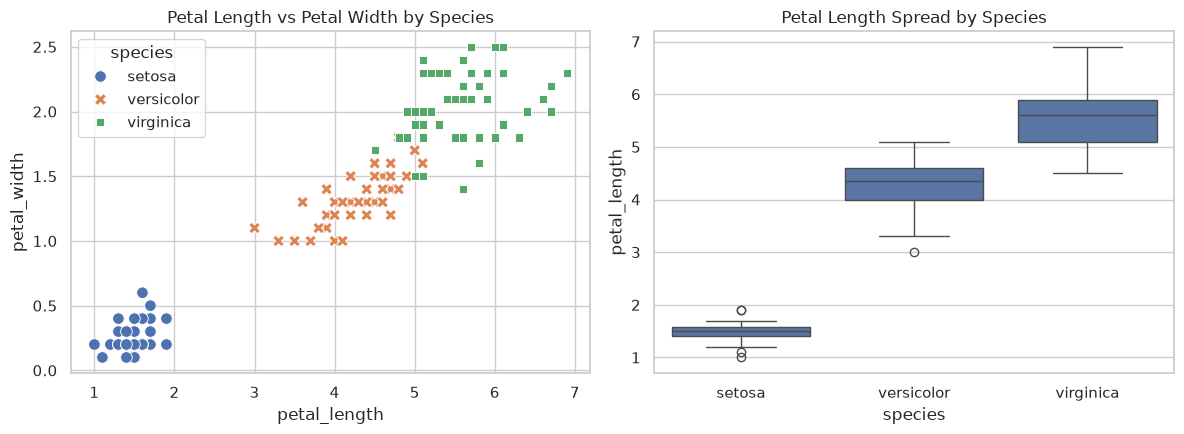

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", style="species", s=70, ax=axes[0])
axes[0].set_title("Petal Length vs Petal Width by Species")

sns.boxplot(data=df, x="species", y="petal_length", ax=axes[1])
axes[1].set_title("Petal Length Spread by Species")
plt.tight_layout(); plt.show()

Data set 5 palmer penguins

In [54]:
df = sns.load_dataset("penguins")
print("Shape:", df.shape)
df = df.drop_duplicates()
df = df.dropna(subset=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"])
df["sex"] = df["sex"].fillna("unknown")
print("Shape after cleaning:", df.shape)
df.head()

Shape: (344, 7)
Shape after cleaning: (342, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


cleaning on data set 5

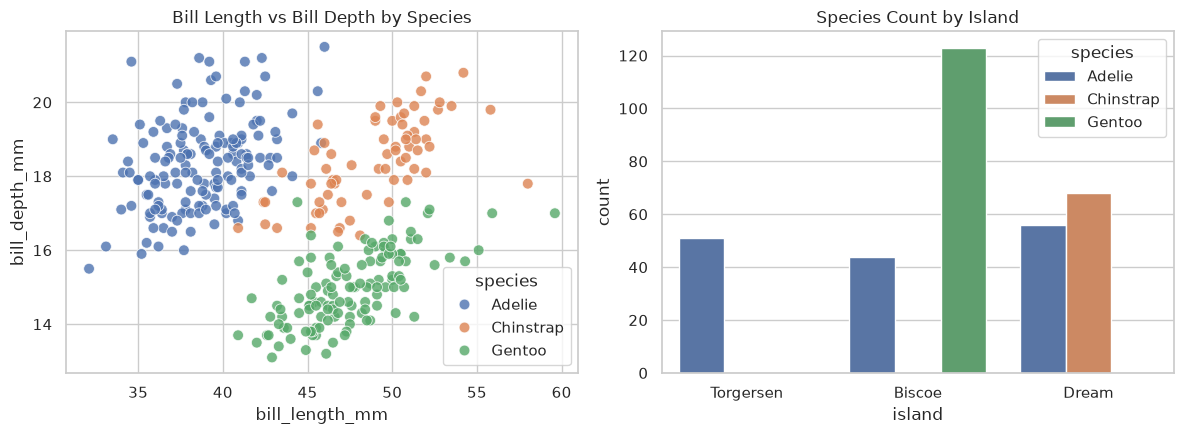

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=axes[0], s=60, alpha=0.8)
axes[0].set_title("Bill Length vs Bill Depth by Species")

sns.countplot(data=df, x="island", hue="species", ax=axes[1])
axes[1].set_title("Species Count by Island")
plt.tight_layout(); plt.show()

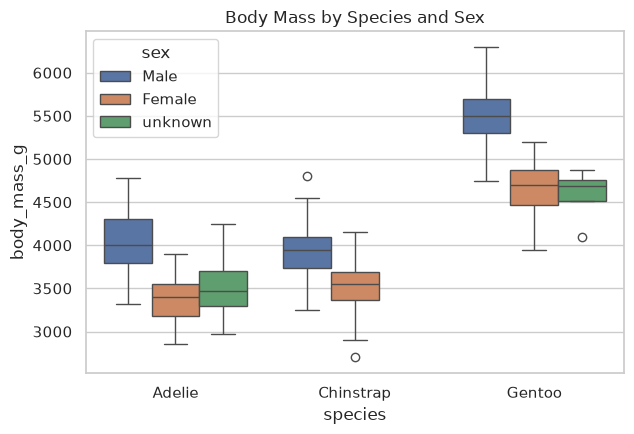

In [56]:
fig, ax = plt.subplots(figsize=(6.5,4.5))
sns.boxplot(data=df, x="species", y="body_mass_g", hue="sex", ax=ax)
ax.set_title("Body Mass by Species and Sex")
plt.tight_layout(); plt.show()

Dataset 6 Auto MPG - fuel efficiency

In [57]:
df = sns.load_dataset("mpg")
print("Shape:", df.shape)
df = df.drop_duplicates()
n_missing_hp = df["horsepower"].isna().sum()
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())
df["name"] = df["name"].str.strip()
print(f"Filled {n_missing_hp} missing horsepower values (raw '?' entries) with the median.")
df.head()

Shape: (398, 9)
Filled 6 missing horsepower values (raw '?' entries) with the median.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


cleaning on dataset 6

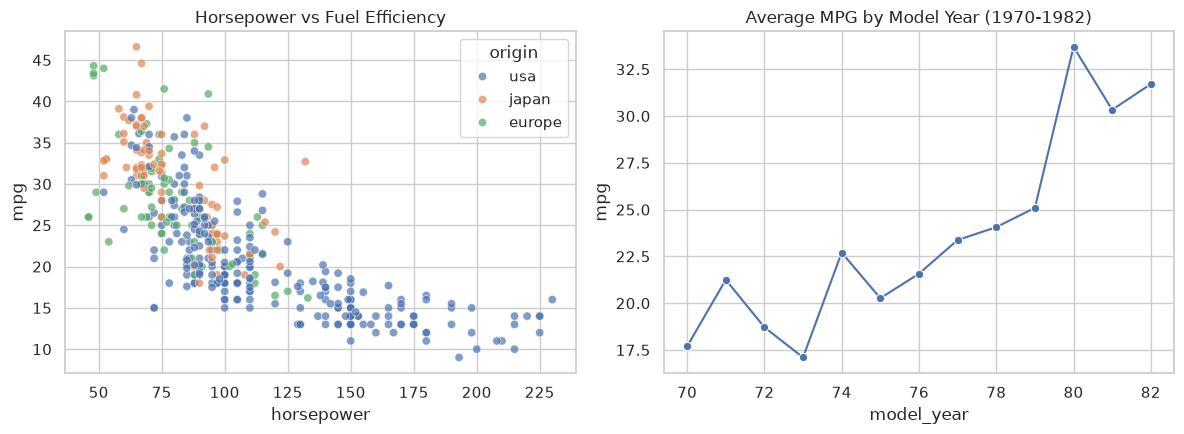

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.scatterplot(data=df, x="horsepower", y="mpg", hue="origin", ax=axes[0], alpha=0.7)
axes[0].set_title("Horsepower vs Fuel Efficiency")

trend = df.groupby("model_year")["mpg"].mean().reset_index()
sns.lineplot(data=trend, x="model_year", y="mpg", marker="o", ax=axes[1])
axes[1].set_title("Average MPG by Model Year (1970-1982)")
plt.tight_layout(); plt.show()

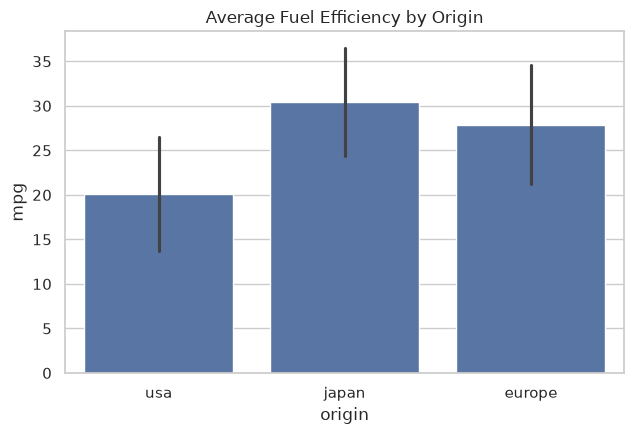

In [59]:
fig, ax = plt.subplots(figsize=(6.5,4.5))
sns.barplot(data=df, x="origin", y="mpg", ax=ax, errorbar="sd")
ax.set_title("Average Fuel Efficiency by Origin")
plt.tight_layout(); plt.show()

Dataset 7 car crashes 

In [60]:
df = sns.load_dataset("car_crashes")
print("Shape:", df.shape, "| duplicates:", df.duplicated().sum(), "| missing:", df.isna().sum().sum())
df = df.drop_duplicates()
df.head()

Shape: (51, 8) | duplicates: 0 | missing: 0


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


cleaning on dataset 7

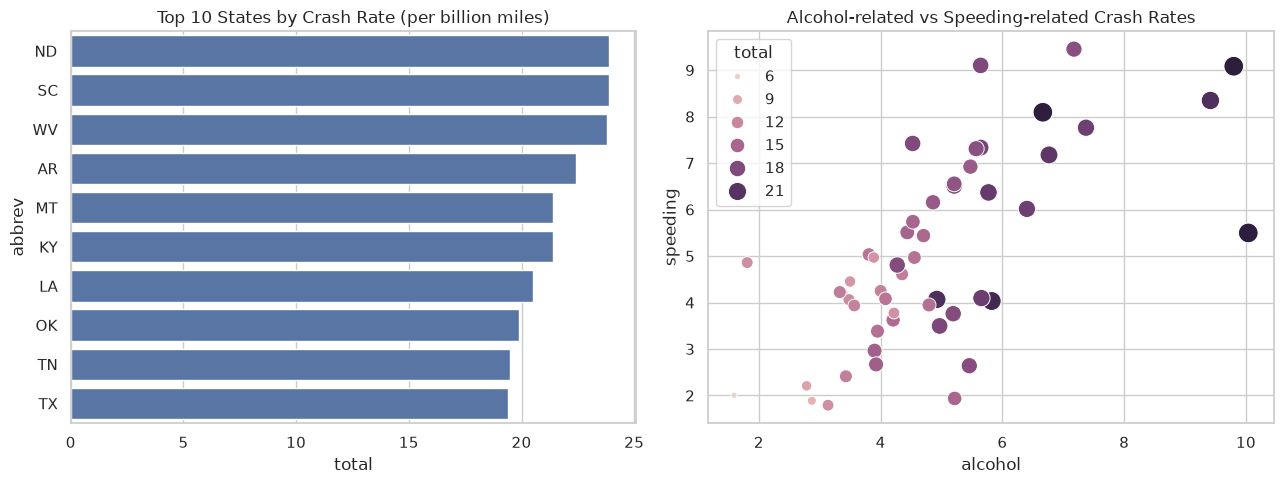

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
top10 = df.sort_values("total", ascending=False).head(10)
sns.barplot(data=top10, y="abbrev", x="total", ax=axes[0], orient="h")
axes[0].set_title("Top 10 States by Crash Rate (per billion miles)")

sns.scatterplot(data=df, x="alcohol", y="speeding", size="total", hue="total", ax=axes[1], sizes=(20,200))
axes[1].set_title("Alcohol-related vs Speeding-related Crash Rates")
plt.tight_layout(); plt.show()

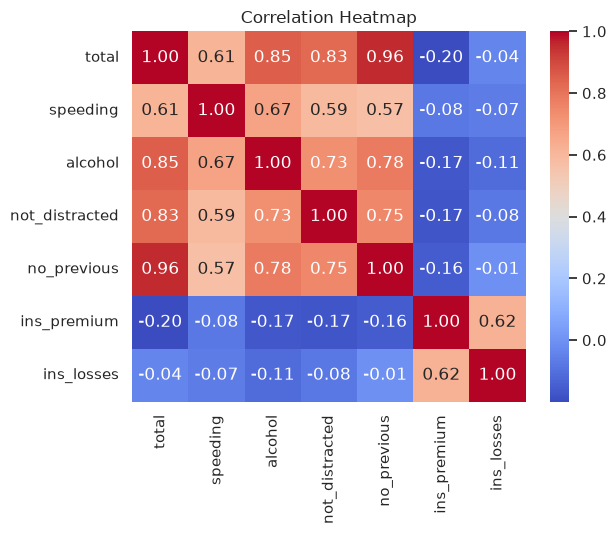

In [62]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
corr = df.drop(columns=["abbrev"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax, fmt=".2f")
ax.set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

Dataset 8  flights

In [63]:
df = sns.load_dataset("flights")
print("Shape:", df.shape, "| duplicates:", df.duplicated().sum(), "| missing:", df.isna().sum().sum())
df = df.drop_duplicates()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str), format="%Y-%b")
df.head()

Shape: (144, 3) | duplicates: 0 | missing: 0


,year,month,passengers,date
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01
3,1949,Apr,129,1949-04-01
4,1949,May,121,1949-05-01


cleaning on dataset 8

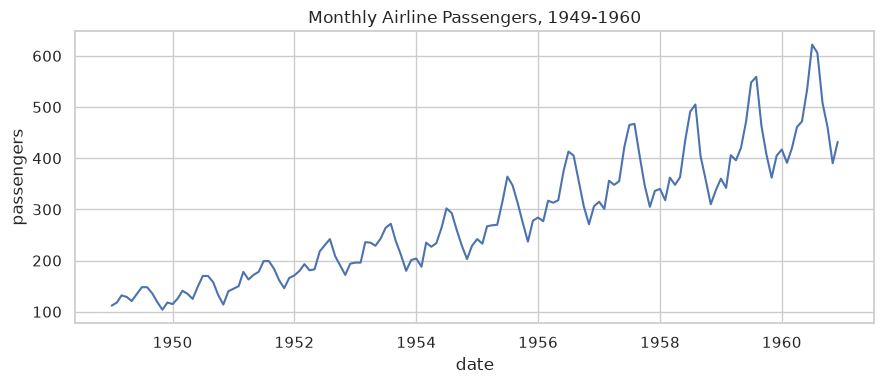

In [64]:
fig, ax = plt.subplots(figsize=(9,4))
sns.lineplot(data=df, x="date", y="passengers", ax=ax)
ax.set_title("Monthly Airline Passengers, 1949-1960")
plt.tight_layout(); plt.show()

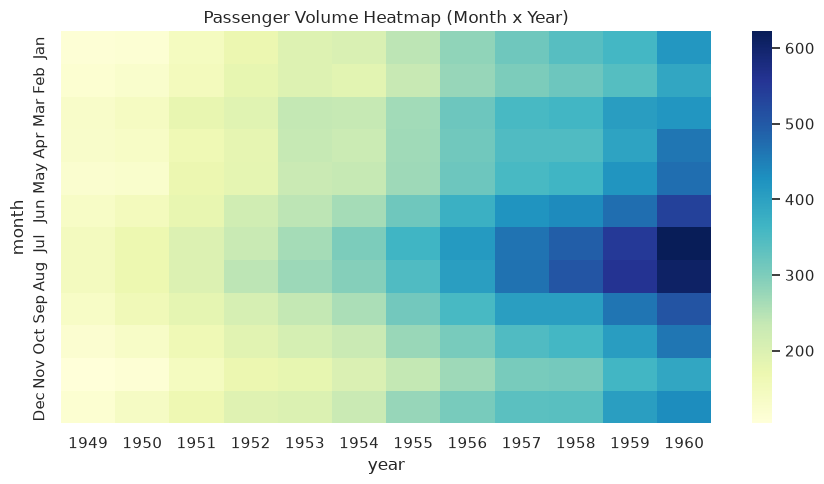

In [65]:
fig, ax = plt.subplots(figsize=(9,5))
pivot = df.pivot(index="month", columns="year", values="passengers")
sns.heatmap(pivot, cmap="YlGnBu", ax=ax)
ax.set_title("Passenger Volume Heatmap (Month x Year)")
plt.tight_layout(); plt.show()

Dataset 9 Planets

In [66]:
df = sns.load_dataset("planets")
print("Shape:", df.shape)
df = df.drop_duplicates()
print(df[["mass","distance","orbital_period"]].isna().sum())
df.head()

Shape: (1035, 6)
mass              518
distance          224
orbital_period     39
dtype: int64


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


Cleaning on dataset 9

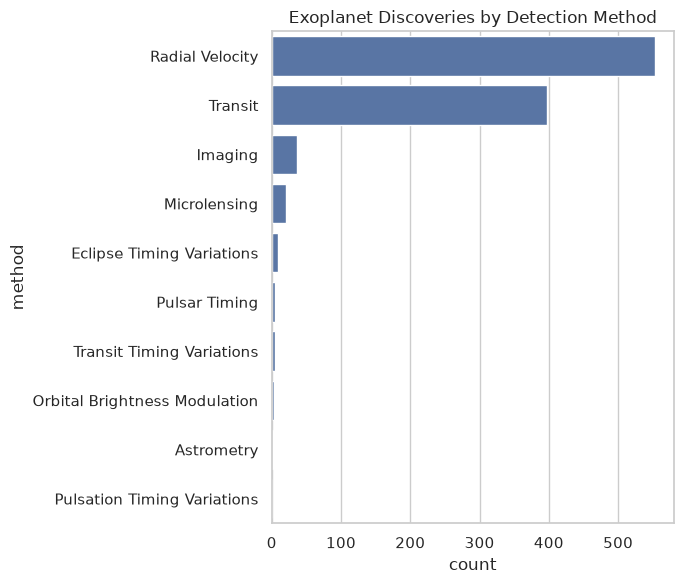

In [67]:
fig, ax = plt.subplots(figsize=(7,6))
order = df["method"].value_counts().index
sns.countplot(data=df, y="method", order=order, ax=ax)
ax.set_title("Exoplanet Discoveries by Detection Method")
plt.tight_layout(); plt.show()

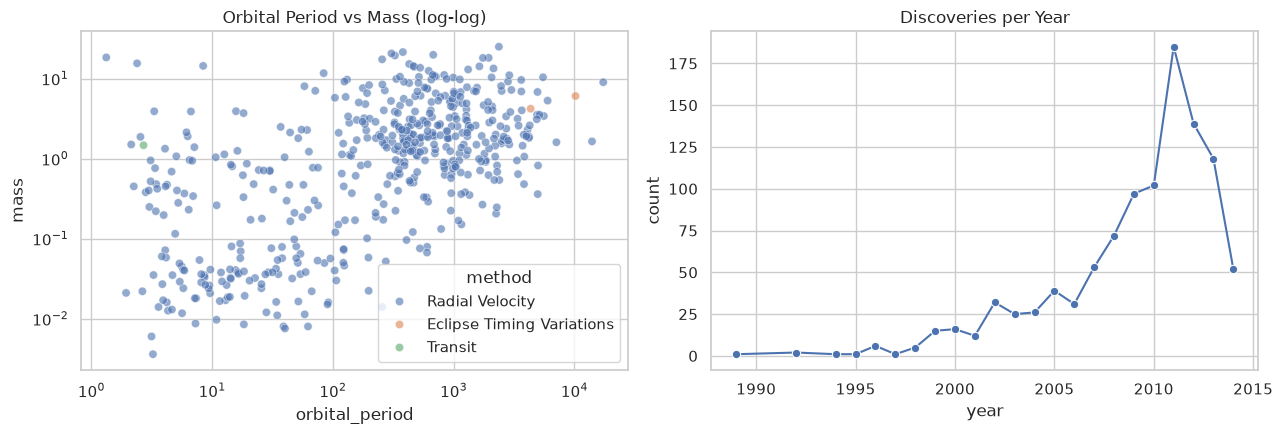

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sub = df.dropna(subset=["orbital_period","mass"])
sns.scatterplot(data=sub, x="orbital_period", y="mass", hue="method", alpha=0.6, ax=axes[0])
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Orbital Period vs Mass (log-log)")

yearly = df.groupby("year").size().reset_index(name="count")
sns.lineplot(data=yearly, x="year", y="count", marker="o", ax=axes[1])
axes[1].set_title("Discoveries per Year")
plt.tight_layout(); plt.show()

Dataset 10 NYC taxis

In [69]:
df = sns.load_dataset("taxis")
print("Shape:", df.shape)
df = df.drop_duplicates()
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])
df["pickup_borough"] = df["pickup_borough"].fillna("Unknown")
df["dropoff_borough"] = df["dropoff_borough"].fillna("Unknown")
df["pickup"] = pd.to_datetime(df["pickup"])
df["dropoff"] = pd.to_datetime(df["dropoff"])
df["pickup_hour"] = df["pickup"].dt.hour
df = df[df["fare"] > 0]
print("Shape after cleaning:", df.shape)
df.head()

Shape: (6433, 14)
Shape after cleaning: (6433, 15)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,pickup_hour
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,20
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,16
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,17
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,13


cleaning on dataset 10

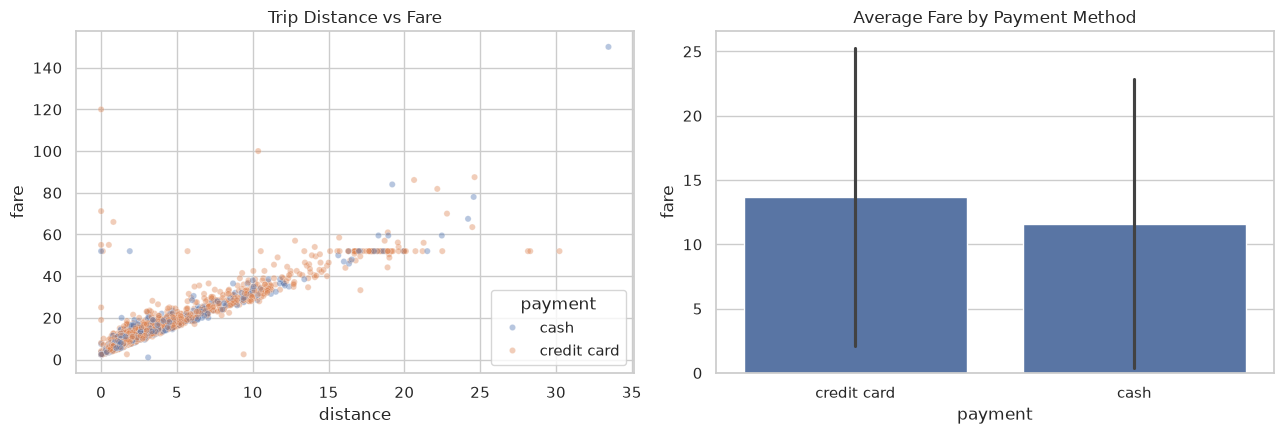

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sample = df.sample(min(3000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="distance", y="fare", hue="payment", alpha=0.4, ax=axes[0], s=20)
axes[0].set_title("Trip Distance vs Fare")

sns.barplot(data=df, x="payment", y="fare", ax=axes[1], errorbar="sd")
axes[1].set_title("Average Fare by Payment Method")
plt.tight_layout(); plt.show()

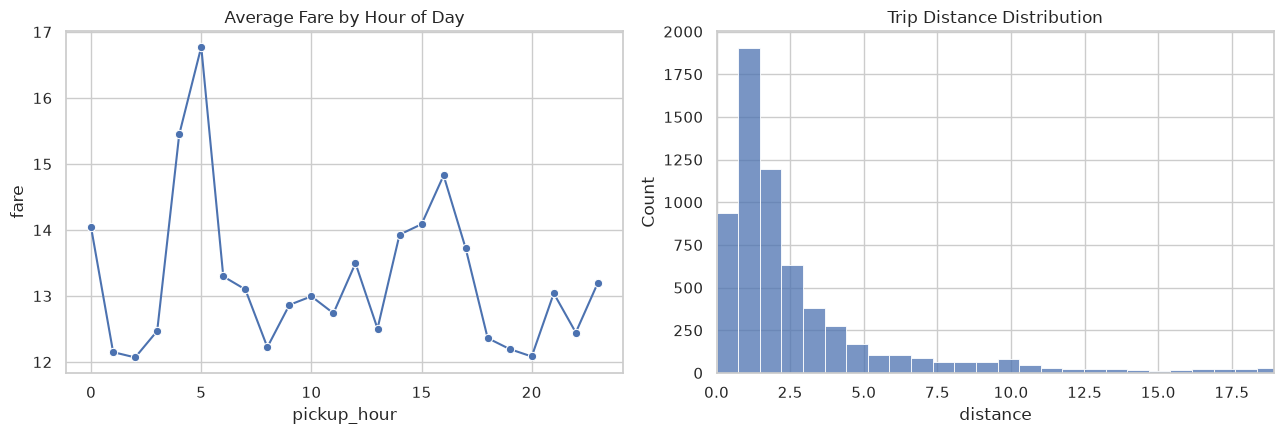

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
hourly = df.groupby("pickup_hour")["fare"].mean().reset_index()
sns.lineplot(data=hourly, x="pickup_hour", y="fare", marker="o", ax=axes[0])
axes[0].set_title("Average Fare by Hour of Day")

sns.histplot(df["distance"], bins=50, ax=axes[1])
axes[1].set_xlim(0, df["distance"].quantile(0.99))
axes[1].set_title("Trip Distance Distribution")
plt.tight_layout(); plt.show()